## Set parameters

In [ ]:
total_contour_points = 0

# Iterate through the contours and count the points in each contour
for contour in contours:
    contour_points = contour.reshape(-1, 2)  # Flatten the contour to get the (x, y) points
    total_contour_points += len(contour_points)  # Add the number of points in this contour to the total

# Print the total number of contour points
print(f"Total number of contour points: {total_contour_points}")

In [ ]:


import numpy as np
import cv2
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from matplotlib import colors
import pandas as pd
import csv

smoothing_size = 100
extension_factor = 1.1; 
step_size = 2;
max_width = 2048
overlap_threshold = 0.3
weight_epithelium_coverage = 0.8
weight_background_pixels = 0.2

# Function to draw patches
def draw_patches(image, patch_list, color = [255,0,0], thickness = 20):
    patches_on_slice = image.copy()
    for contour_patches in patch_list:
        for patch in contour_patches:
            points = patch.astype(np.int32)
            cv2.polylines(patches_on_slice, [points], isClosed = True, color = color, thickness = thickness)        
    return patches_on_slice

# Function to calculate patch overlap
def patch_overlap(square1,square2):

    square1 = Polygon(square1)
    square2 = Polygon(square2)

    if not square1.intersects(square2):
        return 0
    
    intersection_area = square1.intersection(square2).area
    smallest_area = min(square1.area,square2.area)
    return intersection_area/smallest_area

def adaptive_smoothing_size(num_contour_points):
    return max(100, int(num_contour_points * 0.05))




Total number of contour points: 3669


h2114171 h&e_ROI_3.tif h&e_highgrade_case18_match1.png
Total Coverage: 93.78%
Background Pixel Percentage: 28.67%
Score Percentage: 89.29%
h2114171 melan_ROI_2.tif melan_highgrade_case18_match1.png
Total Coverage: 90.75%
Background Pixel Percentage: 21.98%
Score Percentage: 88.20%
h2114171 sox10_ROI_1.tif sox10_highgrade_case18_match1.png
Total Coverage: 95.91%
Background Pixel Percentage: 30.04%
Score Percentage: 90.72%


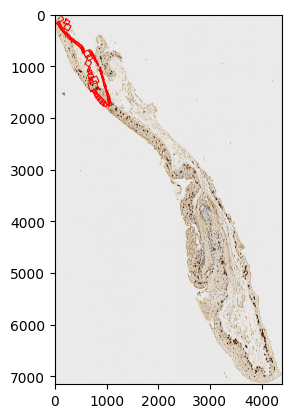

In [2]:
# Define the patient number and case/match details
patient_number = "h2114171"  # Example patient number
case_match = "highgrade_case18_match1"  # Example case/match

# Define the stain types and their corresponding ROI numbers
stain_roi_map = {
    "h&e": "3",
    "melan": "2",
    "sox10": "1"
}

# Iterate through each stain type and its respective ROI number
for stain, roi_number in stain_roi_map.items():
    slice_name = f"{patient_number} {stain}_ROI_{roi_number}.tif"
    slice_detail = f"{stain}_{case_match}"

    mask_name = slice_detail + ".png"
    patched_slice_name = "output/patched_" + mask_name
    metrics_file_name = "output/metrics_before_improvement_" + slice_detail + ".csv"
    patch_length_filename = "output/patch_lengths_before_improvement" + slice_detail + ".csv"

    print (slice_name, mask_name)
    tissue_slice = cv2.cvtColor(cv2.imread("cases/" + slice_name), cv2.COLOR_BGR2RGB)
    epithelium_mask = cv2.cvtColor(cv2.imread("cases/" + mask_name), cv2.COLOR_BGR2RGB)
    epithelium_mask_gray = cv2.cvtColor(epithelium_mask, cv2.COLOR_RGB2GRAY)
    Otsu_threshold, epithelium_mask_2D = cv2.threshold(epithelium_mask_gray, 0, 255, 
                                cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # Getting contours
    contours, hierarchy = cv2.findContours(epithelium_mask_2D, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Getting tangents and normals on contour points
    all_normals=[]
    all_tangents = []

    for contour in contours:

        contour_points = contour.reshape(-1,2)
        num_contour_points = len(contour_points)
        smoothing_size = adaptive_smoothing_size(num_contour_points)  # Dynamic smoothing size

        tangents = np.zeros_like(contour_points, dtype = float)

        for i in range(num_contour_points):
            
            prev_idx = (i - smoothing_size) % num_contour_points 
            
            next_idx = (i + smoothing_size) % num_contour_points 
            
            tangent = contour_points[next_idx] - contour_points[prev_idx]
            
            tangent = tangent / (np.linalg.norm(tangent) + 1e-8)
            tangents[i] = tangent            

        normals = np.zeros_like(tangents)
        normals[:,0] = -tangents[:,1]
        normals[:,1] = tangents[:,0]
        
        all_normals.append(normals)
        all_tangents.append(tangents)
        
    all_patches = []
    all_patch_lengths = []
    height, width = epithelium_mask_2D.shape

    # Finding patch corners on each contour
    for c in range(len(contours)):
        contour_points = contours[c].reshape(-1, 2)
        contour_normals = all_normals[c]
        contour_tangents = all_tangents[c]
        contour_patch_lengths = []
        squares = []
        
        for i, point in enumerate(contour_points):
            point = point.astype(int)

            steps = np.arange(0, max_width, step_size)[:, None]
            normal_points = np.clip(point - steps * contour_normals[i], 0, [width - 1, height - 1]).astype(int)

            pixel_values = epithelium_mask_2D[normal_points[:, 1], normal_points[:, 0]]

            stop = np.where(pixel_values == 0)[0]

            epithelium_width = stop[0] * step_size if stop.size > 0 else max_width

            patch_length = int(epithelium_width * extension_factor)
            half_patch_length = patch_length // 2 

            corners = np.array([
                point + (contour_tangents[i] * half_patch_length),
                point - (contour_tangents[i] * half_patch_length),
                point - (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length),
                point + (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length)
            ])
            squares.append(corners)
            contour_patch_lengths.append(patch_length)
        all_patches.append(squares)
        all_patch_lengths.append(contour_patch_lengths)

    all_selected_patches = []
    all_selected_patch_lengths = []

    # Removing highly overlapping contours
    for c in range(len(contours)):
        contour_points = contours[c].reshape(-1, 2)
        
        selected_patches = []
        selected_patch_lengths = []
        for i, point in enumerate(contour_points):
            current_patch = all_patches[c][i]
            current_patch_length = all_patch_lengths[c][i]
            if not any(patch_overlap(current_patch, ith_selected_patch) > overlap_threshold \
                    for ith_selected_patch in selected_patches):
                selected_patches.append(current_patch)
                selected_patch_lengths.append(current_patch_length)
        all_selected_patches.append(selected_patches)
        all_selected_patch_lengths.append(selected_patch_lengths)

    selected_patches_on_slice = draw_patches(tissue_slice, all_selected_patches)

    # Exporting patched slice
    cv2.imwrite(patched_slice_name, cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

    # Calculating performance metrics
    total_epithelium_pixels = (epithelium_mask_2D > 0).sum()
    patch_mask = np.zeros_like(epithelium_mask_2D, dtype=np.uint8)

    #For all patches in all contours, use them to create a mask
    for contour_patches in all_selected_patches:
        for patch in contour_patches:
            patch = np.array(patch,dtype = np.int32).reshape(-1, 1, 2)
            cv2.fillPoly(patch_mask, [patch], 255)

    number_of_patch_mask_pixels = np.count_nonzero(patch_mask > 0)

    covered_epithelium_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D > 0))
    covered_background_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D == 0))

    total_epithelium_coverage = (covered_epithelium_pixels / total_epithelium_pixels*100)
    background_pixel_percent = (covered_background_pixels / number_of_patch_mask_pixels*100)
    score = weight_epithelium_coverage*total_epithelium_coverage + weight_background_pixels*(100 - background_pixel_percent)

    # Exporting performance metrics and parameter values
    metrics = pd.DataFrame({'Metric':['total_epithelium_coverage', 'background_pixel_percent',
                        'score', 'smoothing_size', 'extension_factor', 'step_size',
                        'max_width', 'overlap_threshold'], 
                'Value':[total_epithelium_coverage, background_pixel_percent, score, 
                        smoothing_size, extension_factor, step_size, max_width, overlap_threshold]})

    metrics.to_csv(metrics_file_name, index=False)

    # Exporting patch lengths
    max_length = max(len(contour_patch_lengths) for contour_patch_lengths in all_selected_patch_lengths)

    padded_list = [contour_patch_lengths + [''] * (max_length - len(contour_patch_lengths)) \
                for contour_patch_lengths in all_selected_patch_lengths]

    transposed_list = list(map(list, zip(*padded_list)))

    with open(patch_length_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerows(transposed_list)

    plt.imshow(selected_patches_on_slice);
    print(f"Total Coverage: {total_epithelium_coverage:.2f}%")
    print(f"Background Pixel Percentage: {background_pixel_percent:.2f}%")
    print(f"Score Percentage: {score:.2f}%")
    